# Steel Defect Detection — EDA & Evaluation

Dataset: NEU-CLS (1,800 grayscale images, 6 defect classes, 300 each).
This notebook looks at the raw data, then loads the trained model's
held-out test results. Training itself lives in `src/train_model.py` —
this notebook is for inspection, not for re-running the training loop.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from model import CLASS_NAMES

print("Project root:", ROOT)
print("Classes:", CLASS_NAMES)

Project root: /Users/tiashaverse/steel-defect-detection
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## 1. Dataset overview

One sample image per class, straight from `data/raw/`.

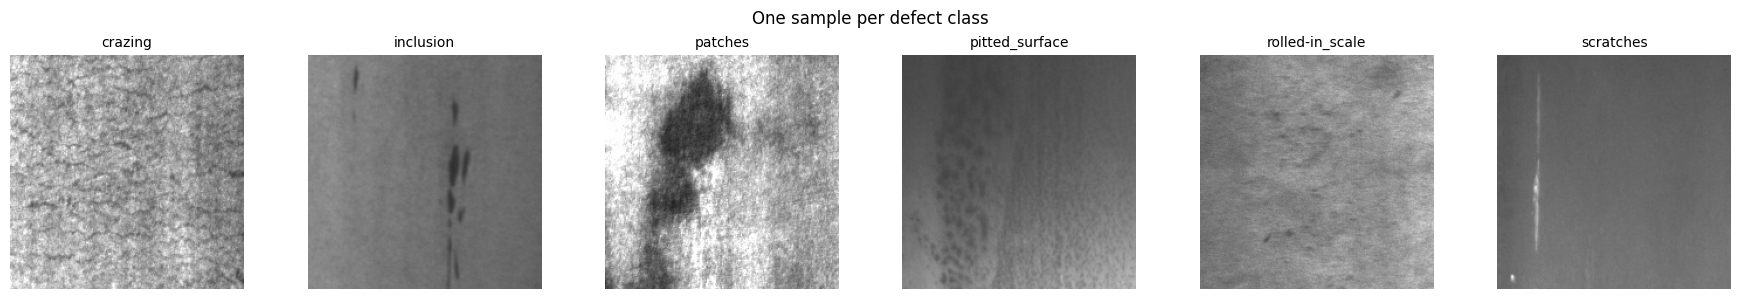

In [2]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 3))
for ax, class_name in zip(axes, CLASS_NAMES):
    sample_path = sorted((ROOT / "data" / "raw" / class_name).glob("*.jpg"))[0]
    image = Image.open(sample_path)
    ax.imshow(image, cmap="gray")
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")
plt.suptitle("One sample per defect class")
plt.tight_layout()
plt.show()

## 2. Class balance

NEU-CLS is balanced by construction (300 images per class) — confirming that here rather than assuming it.

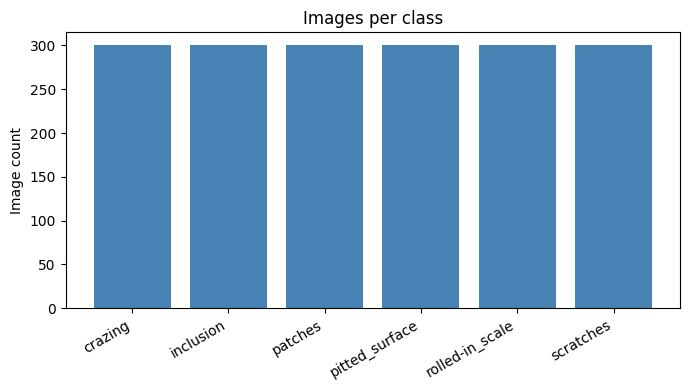

{'crazing': 300,
 'inclusion': 300,
 'patches': 300,
 'pitted_surface': 300,
 'rolled-in_scale': 300,
 'scratches': 300}

In [3]:
counts = {
    class_name: len(list((ROOT / "data" / "raw" / class_name).glob("*.jpg")))
    for class_name in CLASS_NAMES
}
plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.ylabel("Image count")
plt.title("Images per class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
counts

## 3. Train/val/test split

Generated by `src/prepare_data.py` — a stratified 70/15/15 split, fixed seed, no time dimension in this data so a random split (rather than a time-based one, as in the Olist project) is the right call.

In [4]:
import pandas as pd

manifest = pd.read_csv(ROOT / "data" / "processed" / "manifest.csv")
manifest.groupby(["split", "label"]).size().unstack()

label,crazing,inclusion,patches,pitted_surface,rolled-in_scale,scratches
split,,,,,,
test,45,45,45,46,45,45
train,210,210,210,210,210,210
val,45,45,45,44,45,45


## 4. Held-out test set results

Loaded from `models/metrics.json`, written by `src/train_model.py` after training. Backbone: MobileNetV2, frozen, with only the classifier head trained on cached embeddings (see the README's engineering-decisions section for why).

In [5]:
metrics = json.loads((ROOT / "models" / "metrics.json").read_text())
print(f"Test accuracy: {metrics['accuracy']:.3f}")
print(f"Macro F1: {metrics['macro_avg']['f1-score']:.3f}")
print(f"Trained at: {metrics['trained_at']}")
pd.DataFrame(metrics["per_class"]).T

Test accuracy: 0.993
Macro F1: 0.993
Trained at: 2026-09-27T01:01:06.454726+00:00


,precision,recall,f1-score,support
crazing,1.000000,1.000000,1.000000,45.0
inclusion,1.000000,0.955556,0.977273,45.0
patches,1.000000,1.000000,1.000000,45.0
pitted_surface,0.958333,1.000000,0.978723,46.0
rolled-in_scale,1.000000,1.000000,1.000000,45.0
scratches,1.000000,1.000000,1.000000,45.0


## 5. Confusion matrix

Generated by `src/train_model.py`, saved to `reports/confusion_matrix.png`.

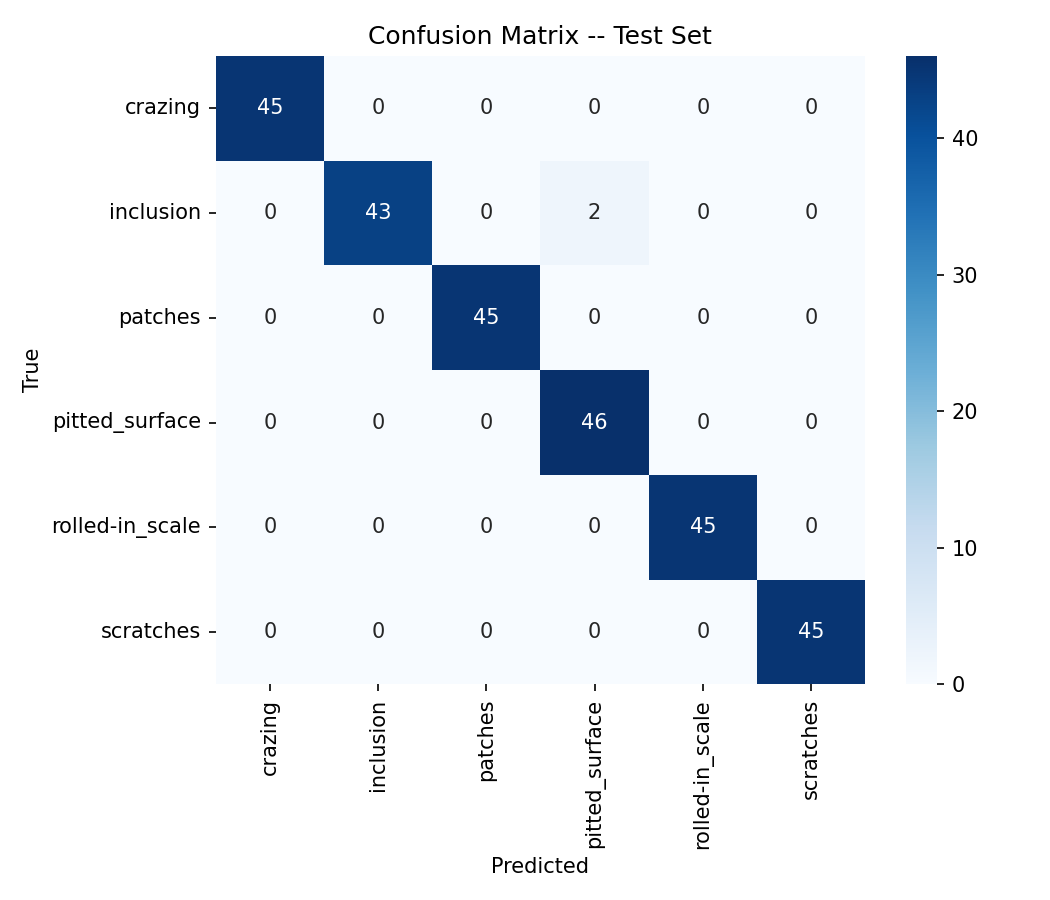

In [6]:
from IPython.display import Image as IPImage

IPImage(filename=str(ROOT / "reports" / "confusion_matrix.png"))

## 6. Reading the mistakes

Only 2 of 271 test images were misclassified. Let's see which ones.

In [7]:
import numpy as np

cm = np.array(metrics["confusion_matrix"])
class_names = metrics["class_names"]
for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        if i != j and cm[i, j] > 0:
            print(f"{cm[i, j]}x true={true_class} predicted={pred_class}")

2x true=inclusion predicted=pitted_surface


Both errors are `inclusion` misclassified as `pitted_surface` — the two
defect types that look most alike (small dark surface irregularities),
even by eye. See the README's *Limitations* section for why this
near-perfect accuracy shouldn't be read as "production ready."